In [ ]:
# Fix stalling - BLAS thread contention.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
# then numpy / sklearn imports

In [1]:
# Import Packages (churn legacy ***clean up***)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import math
from datetime import datetime, timedelta
#from scipy.stats import loguniform, randint, uniform, skew
#import statsmodels.api as sm
#from sklearn.linear_model import LogisticRegression
#from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_s
#from sklearn.model_selection import cross_val_score, StratifiedKFold, Randomize
from sklearn.preprocessing import StandardScaler, RobustScaler
#from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingCl

# Recomended
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import f_oneway
from sklearn.cluster import HDBSCAN

#import optuna
#import shap

# Set Display Preferences
pd.set_option('display.max_columns', None)
pd.options.display.float_format = "{:.2f}".format

#import gc
np.random.seed(1)

In [2]:
# Load Instacart data
aisles = pd.read_csv("data/raw/aisles.csv")
departments = pd.read_csv("data/raw/departments.csv")
order_products__prior = pd.read_csv("data/raw/order_products__prior.csv")
    # contains the products for each past order & then the test & train datasets are for the customers final order
    # len = 32.4M rows (train len only 1.4M & doesnt include eval_set = test)
    # Neither order_products_x contain eval_set = test
    # Does reordered mean that customer has purchased that product in the past. if first purchase, reorder still = 0 instead of null
    # The goal of the original sompetition was to predict which previously purchased products will be in a user’s next order.
order_products__train = pd.read_csv("data/raw/order_products__train.csv")
    # len = 1.38M rows
    # The goal of the original competition was to predict which previously purchased products will be in a user’s next order.
        # so customer i has purchased x different products. objectice is to calc/predict which of those x items shows up in their final order.
        # achieved by calculating a proability (forecast?) for each previous item & if prob > a threshold then predict it will be in final order
            # note: so do we not care about the new items in the final order?????
orders = pd.read_csv("data/raw/orders.csv")
    # contains all orders by all customers in but the prior, train & test sets
    # a customers last order is categorized into train or test
    # a customers first order (order_num=1) has a blank days_since_prior_order which makes sense. sometimes users make multiple orders in 1 day making value of this factor = 0.
        # note: there are a lot of same day orders -> probably dont repeate same products in 1 day
    # max days since reorder is 30 days so 30 actually = 30+
products = pd.read_csv("data/raw/products.csv")


In [3]:
order_products = pd.concat([order_products__prior, order_products__train], ignore_index=True)
df = orders.merge(order_products, how='inner', on='order_id')
df = df.merge(products, how='left', on='product_id')
df = df.merge(aisles, how='left', on='aisle_id')
df = df.merge(departments, how='left', on='department_id')



In [4]:
# Department -> product_cat  (beverages intentionally omitted; handled by aisle below)
dept_to_cat = {
    'produce':         'produce',
    'dairy eggs':      'dairy eggs',
    'meat seafood':    'meat seafood', 
    'snacks':          'indulgence',          
    'dry goods pasta': 'staples',
    'canned goods':    'staples',
    'pantry':          'staples',
    'breakfast':       'staples',
    'bulk':            'staples',
    'deli':            'prepared',
    'bakery':          'prepared',
    'frozen':          'prepared',
    'household':       'non_consumables',
    'personal care':   'non_consumables',
    # standalone markers (kept distinct so they can be exluded from CLR block)
    'alcohol':         'alcohol',
    'babies':          'babies',
    'pets':            'pets',
    'international':   'international',
    # drop
    'other':           'other',
    'missing':         'other',}

# Beverage aisle -> product_cat
bev_to_cat = {
    'water seltzer sparkling water': 'staples',
    'refrigerated':                  'staples',
    'juice nectars':                 'staples',
    'tea':                           'staples',
    'coffee':                        'staples',
    'soft drinks':                   'indulgence',
    'energy sports drinks':          'indulgence',
    'cocoa drink mixes':             'indulgence',}

# Map department (beverages -> NaN here)
df['product_cat'] = df['department'].map(dept_to_cat)
# Map beverages by aisle
bev = df['department'] == 'beverages'
df.loc[bev, 'product_cat'] = df.loc[bev, 'aisle'].map(bev_to_cat)

# Safety check — print unmapped departments/ailes (check for NaN)
print(df['product_cat'].value_counts(dropna=False))

product_cat
produce            9888378
staples            7051743
dairy eggs         5631067
prepared           4657579
indulgence         3510861
non_consumables    1243345
meat seafood        739238
babies              438743
international       281155
alcohol             159294
other               115482
pets                102221
Name: count, dtype: int64


In [5]:
core_cats   = ['produce', 'dairy eggs', 'meat seafood','indulgence', 'staples', 'prepared', 'non_consumables']
marker_cats = ['alcohol', 'babies', 'pets', 'international']

# Transpose item counts by category to a new df
cat_counts = (df[df['product_cat'] != 'other']
              .groupby(['user_id', 'product_cat']).size()
              .unstack(fill_value=0))
for c in core_cats + marker_cats:                                   # ensure all columns exist
    if c not in cat_counts.columns:
        cat_counts[c] = 0

# CLR block — core categories only
    # Re-expresses each category as its log-representation relative to the customer's own mean basket, 
    # Mapping the composition into unconstrained Euclidean space where distances behave and the values stay interpretable 
    # Note: positive = that customer over-indexes on this category relative to their own mix)
    # Note: fixes sum-to-1 constraint that created spurious dependence + values now live in a flat Euclidean space rahter than a constrained simplex
alpha = 0.5                                                         # additive smoothing -> no zeros
core_smoothed = cat_counts[core_cats].astype(float) + alpha
core_comp = core_smoothed.div(core_smoothed.sum(axis=1), axis=0)    # divide by row total to get smoothed category percentages
log_comp = np.log(core_comp)                                        # take log

clr = log_comp.sub(log_comp.mean(axis=1), axis=0)                   # subtract mean of row from each value in that row
clr.columns = [f'clr_{c}' for c in core_cats]                       # asign column names
clr

,clr_produce,clr_dairy eggs,clr_meat seafood,clr_indulgence,clr_staples,clr_prepared,clr_non_consumables
user_id,,,,,,,
1,0.30,1.46,-2.10,2.30,0.30,-2.10,-0.15
2,0.89,1.02,-2.48,0.98,0.43,1.12,-1.97
3,1.76,1.17,-2.59,0.36,0.55,0.25,-1.49
4,0.25,-1.35,-1.35,0.25,0.59,1.35,0.25
5,1.95,1.04,-1.91,-0.81,0.49,0.04,-0.81
...,...,...,...,...,...,...,...
206205,1.53,1.88,-0.73,-1.83,-0.22,1.21,-1.83
206206,0.18,0.32,-2.44,0.56,0.56,1.07,-0.25
206207,1.10,1.14,-0.95,0.33,1.24,0.66,-3.52


In [6]:
# EDA on pct of customers that reorder by category. 
product_cat = df.groupby(['product_cat'], as_index=True).agg(
                                            customers_purchased=('user_id', 'nunique'),
                                            customers_reordered = ('user_id', lambda x: x[df.loc[x.index, 'reordered'] > 0].nunique()))

product_cat['customers_purchased_pct'] = round(product_cat['customers_purchased'] / df['user_id'].nunique() * 100, 2)
product_cat['customers_reordered_pct'] = round(product_cat['customers_reordered'] / df['user_id'].nunique() * 100, 2)
product_cat


,customers_purchased,customers_reordered,customers_purchased_pct,customers_reordered_pct
product_cat,,,,
alcohol,16104,9007,7.81,4.37
babies,34782,19358,16.87,9.39
dairy eggs,191861,165703,93.04,80.36
indulgence,183036,136180,88.76,66.04
international,79357,29510,38.48,14.31
meat seafood,116851,70181,56.67,34.03
non_consumables,140269,67532,68.02,32.75
other,44512,15069,21.59,7.31
pets,15484,8057,7.51,3.91


In [7]:
# Define a new column for organic items based on 'organic' appearing in product_name
df['organic'] = df['product_name'].str.contains('organic', case=False, na=False).astype(int)

In [8]:
# Delete very large objects to reduce RAM ussage

del orders, order_products , order_products__prior, order_products__train, bev
del cat_counts, core_comp, core_smoothed, log_comp
#gc.collect() # garbage collection process to reclaim unused memory by finding and destroying unreachable objects

In [9]:
# Calc avg basket size & std dev of avg basket size
basket_sizes = df.groupby(['user_id', 'order_number'], as_index=False).agg(
                                            basket_size=('product_id', 'nunique'),
                                            aisles_breadth=('aisle_id', 'nunique'),
                                            department_breadth=('department_id', 'nunique'))
#basket_sizes = df.groupby(['user_id', 'order_number']).size().reset_index(name='basket_size')

basket_comp = basket_sizes.groupby('user_id').agg(
                                            avg_basket_size=('basket_size', 'mean'),                # Avg basket size of customer_i (small basket vs. large basket shopper)
                                            std_basket_size=('basket_size', 'std'),                 # Variation in basket size of customer_i (routinely basket vs. big swings in behaviour)
                                            avg_aisles_breadth=('aisles_breadth', 'mean'),
                                            std_aisles_breadth=('aisles_breadth', 'std'),           # Redundant - used to calc Relative Standard Deviation
                                            avg_department_breadth=('department_breadth', 'mean'),
                                            std_department_breadth=('department_breadth', 'std')    # Redundant - used to calc Relative Standard Deviation
                                            )

# Take log of skewed columns (2 reasons)
# 1 - Being right-skewed, most ombervations cluster at small-to-moderate baskets, with a long tail of a few huge-basket shoppers. 
    # K-means uses squared Euclidean distance, so distant tail observation pull centroids toward themselves 
    # Result: a handful of outliers can define a cluster's location. Logging compresses the tail (gap from 5→50 becomes comparable to 50→500) 
    # - feature contributes proportionally rather than dominated by extremes.
# 2 - multiplicative vs additive: On raw counts, the distance from a 2 to 4 equalate to the distance from 40 to 42. 
    # But behaviourally, 2→4 is a doubling (a different kind of shopper) while 40→42 is noise. 
    # Log space makes equal ratios equal distances, which matches how basket size scale appropriately.
basket_comp['ln_avg_basket_size'] = np.log(basket_comp['avg_basket_size'])

# Scale standard dev to be independent of cx avg volume (Relative Standard Deviation)
basket_comp['rsd_basket_size'] = basket_comp['std_basket_size'] / basket_comp['avg_basket_size']      
basket_comp['rsd_aisles_breadth'] = basket_comp['std_aisles_breadth'] / basket_comp['avg_aisles_breadth']
basket_comp['rsd_department_breadth'] = basket_comp['std_department_breadth'] / basket_comp['avg_department_breadth']

basket_comp

,avg_basket_size,std_basket_size,avg_aisles_breadth,std_aisles_breadth,avg_department_breadth,std_department_breadth,ln_avg_basket_size,rsd_basket_size,rsd_aisles_breadth,rsd_department_breadth
user_id,,,,,,,,,,
1,6.36,2.11,5.55,1.81,3.82,0.60,1.85,0.33,0.33,0.16
2,15.07,7.06,8.47,2.47,5.73,1.16,2.71,0.47,0.29,0.20
3,7.33,2.10,5.75,1.66,4.08,1.00,1.99,0.29,0.29,0.24
4,3.60,2.07,3.00,1.41,3.00,1.41,1.28,0.58,0.47,0.47
5,9.20,2.68,7.20,2.59,4.20,1.30,2.22,0.29,0.36,0.31
...,...,...,...,...,...,...,...,...,...,...
206205,12.75,6.13,9.25,2.06,5.00,1.41,2.55,0.48,0.22,0.28
206206,4.25,3.23,3.57,1.73,2.81,1.13,1.45,0.76,0.49,0.40
206207,13.94,6.04,11.00,5.03,6.31,2.70,2.63,0.43,0.46,0.43


In [10]:
# Create binary flags that will be used to calculate clustering factors when aggregating to customer level. 
# Note: Time periods determined by examing purchase density accross day.
df['is_weekend']   = df['order_dow'].le(1)
df['is_morning']   = df['order_hour_of_day'].between(5, 11)
df['is_afternoon'] = df['order_hour_of_day'].between(12, 19)
df['is_night']     = ~df['order_hour_of_day'].between(5, 19)
# Note: These categories are low variance / zero-heavy -> kept as standalone markers distinct from CLR block
df['alcohol_reord']         = (df['product_cat'] == 'alcohol') & (df['reordered'] > 0)
df['babies_reord']          = (df['product_cat'] == 'babies') & (df['reordered'] > 0)
df['pets_reord']            = (df['product_cat'] == 'pets') & (df['reordered'] > 0)
df['international_reord']    = (df['product_cat'] == 'international') & (df['reordered'] > 0)

# Group by user_id & create aggregated customer level measures
df_user_id = df.groupby('user_id').agg(
    T_orders_count          = ('order_number', 'nunique'),      # Target var - Number of orders customer_i made
    T_lt_items_count        = ('product_id', 'count'),          # Target var - Lifetime total items purchased (lifetime purchase volume)
    T_unique_products       = ('product_id',    'nunique'),     # Target var - Count of lifetime distinct products customer_i purchased
    T_unique_aisles         = ('aisle_id',      'nunique'),     # Target var - Count of lifetime distinct aisles customer_i purchased from
    T_unique_departments    = ('department_id', 'nunique'),     # Target var - Count of lifetime distinct departments customer_i purchased from
    unique_days             = ('order_dow', 'nunique'),         # Number of distinct days customer_i made an order (habitual weekend repurchaser or more sporadic)
    weekend_orders_pct      = ('is_weekend',   'mean'),         # Pct of orders placed on the weekend 
    morning_orders_pct      = ('is_morning',   'mean'),         # Pct of orders placed in the morning (5:00am - 11:59am)
    afternoon_orders_pct    = ('is_afternoon', 'mean'),         # Pct of orders placed in the afternoon (12:00pm - 7:59pm)
    night_orders_pct        = ('is_night',     'mean'),         # Pct of orders placed at night (8:00pm - 4:59am) ~ Note: sum-to-1 redundancy
    organic_pct             = ('organic',       'mean'),        # Pct of items customer_i purchased that were organic
    # Marker flags for low variation / zero-heavy categories 
    alcohol_flag            = ('alcohol_reord', 'max'),         # Dummy for customers that have ever reordered an 'alcohol' product
    babies_flag             = ('babies_reord', 'max'),          # Dummy for customers that have ever reordered a 'babies' product
    pets_flag               = ('pets_reord', 'max'),            # Dummy for customers that have ever reordered a 'pets' product
    international_flag      = ('international_reord', 'max'),   # Dummy for customers that have ever reordered an 'international' product
)

# Post group by processing:
df_user_id['T_hundred_orders'] = df_user_id['T_orders_count'].ge(100).astype(int)     # Measure of highest volumn cx with >= 100 purchases (dataset limit of 100 purchases per cx)
df_user_id['alcohol_flag'] = df_user_id['alcohol_flag'].astype(int)             # Convert from boolean to binary for clustering algos
df_user_id['babies_flag'] = df_user_id['babies_flag'].astype(int) 
df_user_id['pets_flag'] = df_user_id['pets_flag'].astype(int)
df_user_id['international_flag'] = df_user_id['international_flag'].astype(int)

In [11]:
# Drop first order (order_number == 1) 
df_less1st = df[df['order_number']!=1].copy()

# Discovery = propensity to add new items at the beggining of their order vs starting with reordering familiar items
df_less1st['discover_n5'] = -1 * (df_less1st['reordered'].where(df_less1st['add_to_cart_order'].le(5))-1)   # value (0 or 1) where cart<=5, else NaN 
df_less1st['discover_n3'] = -1 * (df_less1st['reordered'].where(df_less1st['add_to_cart_order'].le(3))-1)

# Group by User ID
df_user_id_less1st = df_less1st.groupby('user_id').agg(
    reorder_rate        = ('reordered',     'mean'),            # 
    discovery_pct_n5    = ('discover_n5',   'mean'),            # Proxy measure of if purchase intention - Is order discovery based or routine items?
    discovery_pct_n3    = ('discover_n3',   'mean'),            # Note: mean skips NaN --> calcing mean among add_to_cart_order column where val <= 3
    )


# Order level: (one row per order)
order_level = df_less1st.drop_duplicates('order_id')[['user_id', 'order_id', 'days_since_prior_order']].copy()                   # NaN on first order -> auto-excluded
order_level['is_sameday'] = order_level['days_since_prior_order'].eq(0)
order_level['is_under7']  = order_level['days_since_prior_order'].between(1,7)
order_level['is_cap30']   = order_level['days_since_prior_order'].ge(30)
order_level['is_under30'] = order_level['days_since_prior_order'].lt(30)

# Group order level by user id to get purchase recency flags
order_frequency = order_level.groupby('user_id').agg(
    T_avg_days_since_prior      = ('days_since_prior_order', 'mean'),   # Measure: speed of order frequency
    std_days_since_prior        = ('days_since_prior_order', 'std'),    # Redundant - used to calc Relative Standard Deviation
    same_day_repurchase_pct     = ('is_sameday', 'mean'),
    same_week_repurchase_pct    = ('is_under7',   'mean'),
    days_since_over30_pct       = ('is_cap30',   'mean'),
    days_since_under30_pct      = ('is_under30', 'mean')                # sum-to-1 redundancy
)

# Scale standard dev to be independent of cx avg cadence (Relative Standard Deviation)
order_frequency['rsd_days_since_prior'] = order_frequency['std_days_since_prior'] / order_frequency['T_avg_days_since_prior']  

# join reorder rate & discover propensity with order frequency 
df_user_id_less1st = df_user_id_less1st.merge(order_frequency, how='inner', on='user_id')
df_user_id_less1st

,reorder_rate,discovery_pct_n5,discovery_pct_n3,T_avg_days_since_prior,std_days_since_prior,same_day_repurchase_pct,same_week_repurchase_pct,days_since_over30_pct,days_since_under30_pct,rsd_days_since_prior
user_id,,,,,,,,,,
1,0.78,0.16,0.07,19.00,9.03,0.10,0.00,0.10,0.90,0.48
2,0.49,0.33,0.31,16.29,10.27,0.00,0.14,0.21,0.79,0.63
3,0.71,0.22,0.12,12.09,5.38,0.00,0.36,0.00,1.00,0.44
4,0.07,1.00,1.00,13.75,9.50,0.25,0.00,0.00,1.00,0.69
5,0.51,0.50,0.42,11.50,5.45,0.00,0.25,0.00,1.00,0.47
...,...,...,...,...,...,...,...,...,...,...
206205,0.41,0.33,0.22,16.67,11.55,0.00,0.00,0.33,0.67,0.69
206206,0.48,0.46,0.38,3.77,3.29,0.06,0.83,0.00,1.00,0.87
206207,0.66,0.20,0.24,14.33,11.54,0.00,0.40,0.27,0.73,0.80


In [12]:
# combine data on user_id & start clustering ()
# with K-means, hierarchical, and HDBSCAN compared explicitly; silhouette and stability for evaluation; PCA kept as a diagnostic, not the input, to preserve interpretability.

# merge & organize (dont think I need a train/test split but need to organize by training factors vs target explanitory vs secondary explanitory)
df_joined = df_user_id.merge(df_user_id_less1st, how='inner', on='user_id')
df_joined = df_joined.merge(basket_comp, how='inner', on='user_id')
df_joined = df_joined.merge(clr, how='inner', on='user_id')
df_joined

#del df

,T_orders_count,T_lt_items_count,T_unique_products,T_unique_aisles,T_unique_departments,unique_days,weekend_orders_pct,morning_orders_pct,afternoon_orders_pct,night_orders_pct,organic_pct,alcohol_flag,babies_flag,pets_flag,international_flag,T_hundred_orders,reorder_rate,discovery_pct_n5,discovery_pct_n3,T_avg_days_since_prior,std_days_since_prior,same_day_repurchase_pct,same_week_repurchase_pct,days_since_over30_pct,days_since_under30_pct,rsd_days_since_prior,avg_basket_size,std_basket_size,avg_aisles_breadth,std_aisles_breadth,avg_department_breadth,std_department_breadth,ln_avg_basket_size,rsd_basket_size,rsd_aisles_breadth,rsd_department_breadth,clr_produce,clr_dairy eggs,clr_meat seafood,clr_indulgence,clr_staples,clr_prepared,clr_non_consumables
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,11,70,19,13,7,4,0.24,0.64,0.36,0.00,0.26,0,0,0,0,0,0.78,0.16,0.07,19.00,9.03,0.10,0.00,0.10,0.90,0.48,6.36,2.11,5.55,1.81,3.82,0.60,1.85,0.33,0.33,0.16,0.30,1.46,-2.10,2.30,0.30,-2.10,-0.15
2,15,226,121,37,13,5,0.42,0.87,0.13,0.00,0.25,0,0,0,1,0,0.49,0.33,0.31,16.29,10.27,0.00,0.14,0.21,0.79,0.63,15.07,7.06,8.47,2.47,5.73,1.16,2.71,0.47,0.29,0.20,0.89,1.02,-2.48,0.98,0.43,1.12,-1.97
3,12,88,33,16,9,4,0.70,0.00,1.00,0.00,0.34,0,0,0,0,0,0.71,0.22,0.12,12.09,5.38,0.00,0.36,0.00,1.00,0.44,7.33,2.10,5.75,1.66,4.08,1.00,1.99,0.29,0.29,0.24,1.76,1.17,-2.59,0.36,0.55,0.25,-1.49
4,5,18,17,14,9,3,0.00,0.33,0.67,0.00,0.11,0,0,0,0,0,0.07,1.00,1.00,13.75,9.50,0.25,0.00,0.00,1.00,0.69,3.60,2.07,3.00,1.41,3.00,1.41,1.28,0.58,0.47,0.47,0.25,-1.35,-1.35,0.25,0.59,1.35,0.25
5,5,46,28,17,10,3,0.65,0.20,0.80,0.00,0.50,0,0,0,1,0,0.51,0.50,0.42,11.50,5.45,0.00,0.25,0.00,1.00,0.47,9.20,2.68,7.20,2.59,4.20,1.30,2.22,0.29,0.36,0.31,1.95,1.04,-1.91,-0.81,0.49,0.04,-0.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206205,4,51,37,20,11,4,0.37,0.00,1.00,0.00,0.41,0,0,0,0,0,0.41,0.33,0.22,16.67,11.55,0.00,0.00,0.33,0.67,0.69,12.75,6.13,9.25,2.06,5.00,1.41,2.55,0.48,0.22,0.28,1.53,1.88,-0.73,-1.83,-0.22,1.21,-1.83
206206,67,285,150,50,16,7,0.43,0.01,0.93,0.06,0.31,0,0,0,1,0,0.48,0.46,0.38,3.77,3.29,0.06,0.83,0.00,1.00,0.87,4.25,3.23,3.57,1.73,2.81,1.13,1.45,0.76,0.49,0.40,0.18,0.32,-2.44,0.56,0.56,1.07,-0.25
206207,16,223,92,46,14,7,0.32,0.35,0.48,0.17,0.53,0,0,0,0,0,0.66,0.20,0.24,14.33,11.54,0.00,0.40,0.27,0.73,0.80,13.94,6.04,11.00,5.03,6.31,2.70,2.63,0.43,0.46,0.43,1.10,1.14,-0.95,0.33,1.24,0.66,-3.52


In [13]:
# Note: Discovery of 14 customers that made all their purchases in a single day - resulting in an undefined rsd_days_since_prior
# Solution: Drop these entries as single day order history breaks core assumption multiple features are built on.
    # Key persona comparison feature, 'purchase cadence' - is meaningless when all purchases are same day.
df_joined = df_joined[~df_joined['rsd_days_since_prior'].isna()]

In [14]:
clustering_factors = ['reorder_rate', 'organic_pct',
                      'discovery_pct_n5',   # 'discovery_pct_n3' (exluded - high correlation)
                      'ln_avg_basket_size', # 'avg_department_breadth', 'avg_aisle_breadth' (exluded - high correlation)
                      'rsd_basket_size',    # 'rsd_aisles_breadth', 'rsd_department_breadth' (exluded - high correlation)
                      'rsd_days_since_prior',
                      'weekend_orders_pct', 
                      'morning_orders_pct', 'afternoon_orders_pct',   # 'night_orders_pct', (exluded - collinearity)
                      'days_since_over30_pct',
                      'same_day_repurchase_pct', 'same_week_repurchase_pct', 
                      'clr_produce', 'clr_dairy eggs', 'clr_meat seafood', 'clr_indulgence', 'clr_staples', 'clr_prepared', 'clr_non_consumables'
                      ]


#   TARGETS  = volume/exposure/cadence-level outcomes the segments should separate
#   MARKERS  = sparse lifestyle flags used to DESCRIBE segments (profilers)
holdout_factors = ['T_avg_days_since_prior', # Cadence measure
                   'T_orders_count', 'T_lt_items_count',  # Volume measures
                   'T_unique_products', 'T_unique_aisles', 'T_unique_departments', # Exposure measure
                   # Secondary marker measures
                   'T_hundred_orders',
                   'alcohol_flag', 
                   'babies_flag', 
                   'pets_flag', 
                   'international_flag'
                   ]
# Target cols answers "does this segment retain/engage differently", while marker cols answer "does this segment have more babies/pets than avg."

In [15]:
# INPUTS: cluster on composition, style, and timing features that are roughly invariant to how much someone uses the product

# OUTPUTS: variable used as a downstream outcome is excluded from the inputs; 
    # life. imevolume: number of items
    # frequency & legacy???
    #
# Note: related-but-distinct variables may remain but are expected to show partial mechanical correlation, which is disclosed.

In [16]:
# Cell 2
INPUT_COLS = clustering_factors 

MARKER_COLS = ["alcohol_flag", "babies_flag", "pets_flag", "international_flag"]
TARGET_COLS = [c for c in holdout_factors if c not in MARKER_COLS]
 
# Right-skewed count-like inputs -> log before scaling (see CELL 4 for why).
# Only avg_basket_size qualifies now; if you re-add a breadth mean, log it too.
#SKEWED_COLS = ["avg_basket_size"]

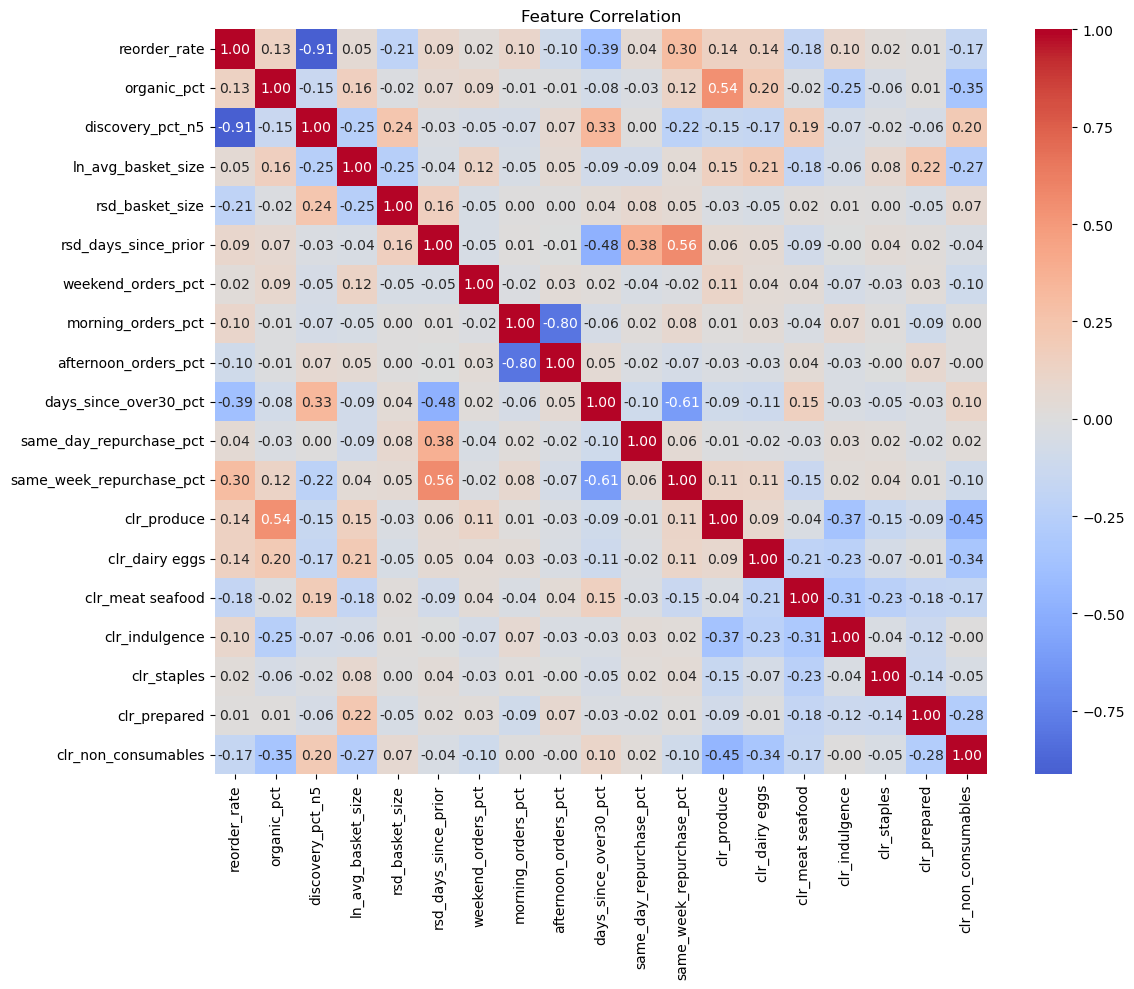

In [17]:
# %% CELL 3 — [ITERATE] Correlation prune --------------------------------------
# WHY: correlated inputs act as hidden double-weights and warp Euclidean distance.
# This is the single highest-leverage cleanup. Watch two blocks in particular:
#   (a) the four cadence-derived features (rsd_days_since_prior, days_since_over30_pct,
#       same_day_repurchase_pct, same_week_repurchase_pct) — all slices of one
#       interval distribution; expect some to collapse together.
#   (b) morning/afternoon dayparts (already dropped night to avoid sum-to-1).

# For any pair > |0.8| - drop one feature
corr = df_joined[clustering_factors].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, 
            annot=True, fmt=".2f")
plt.title("Feature Correlation")
plt.tight_layout(); plt.show()

In [18]:
# Drop one feature from pairs where corr > |0.8|
clustering_factors.remove('discovery_pct_n5')
clustering_factors.remove('afternoon_orders_pct')

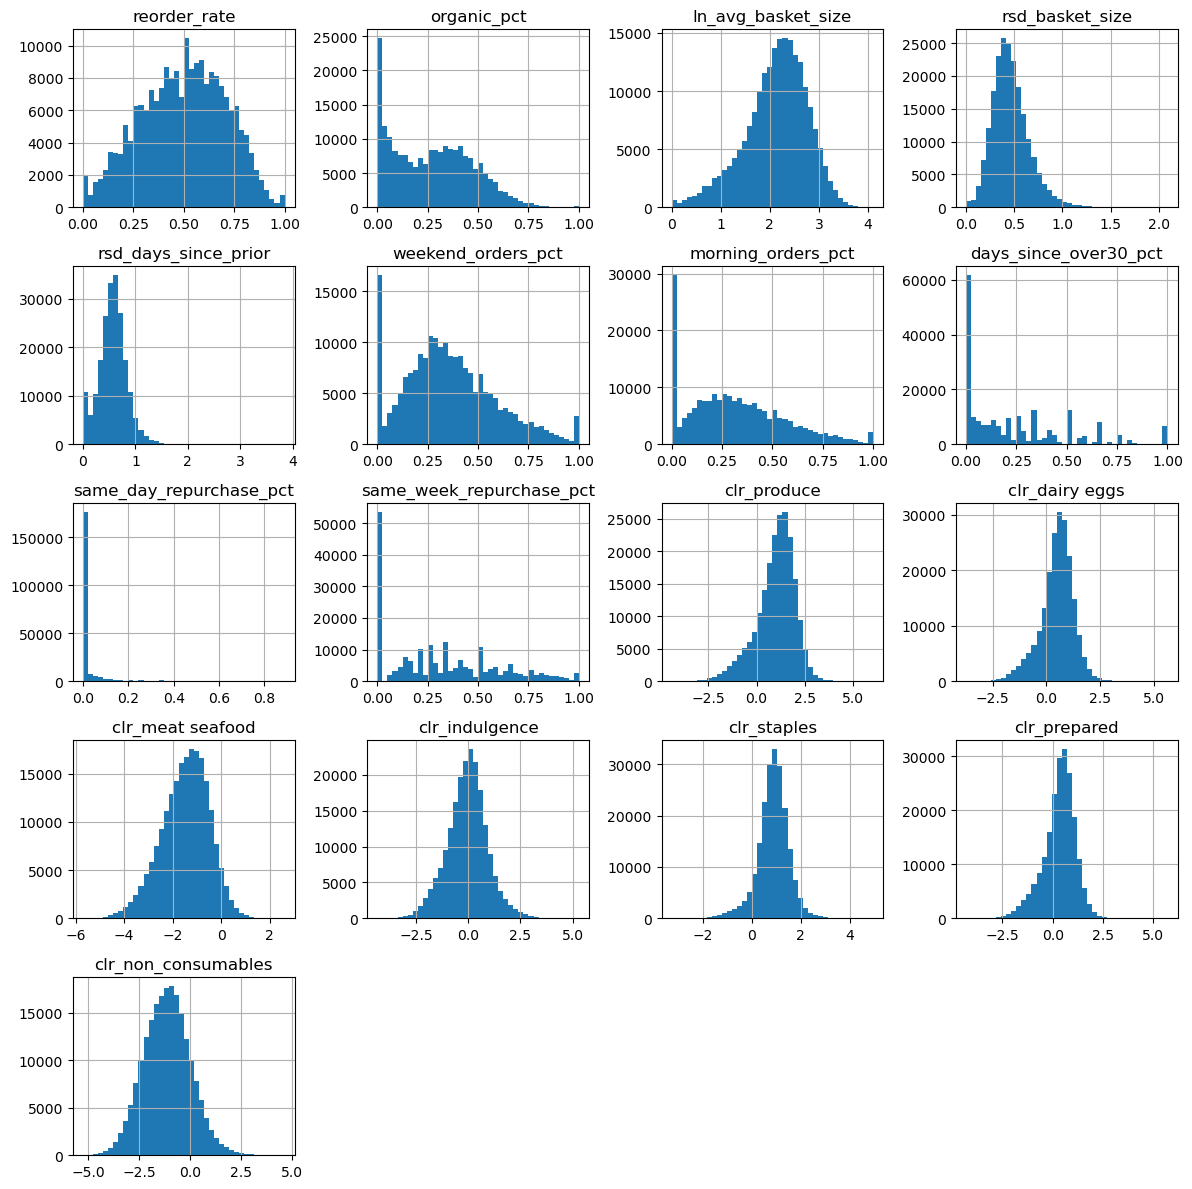

In [19]:
# Distribition / skewness check

# K-means uses squared distance, so a long tails (outliers) pull centroids 
# Logging can compresses the tail AND makes equal *ratios* equal distances (2->4 items ~ 40->80).
# Note: Do not log bounded ratios
df_joined[clustering_factors].hist(figsize=(12, 12), bins=40)
plt.tight_layout(); plt.show()

Implication of spikes at zero: only ~problematic~ for K-means in a specific way: \
K-means minimizes squared distance to a mean, and a large point mass at one value plus a spread-out tail is a non-Gaussian, non-spherical shape. \
The mean sits in the sparse gap between the spike and the tail — a value almost no customer actually has — so the feature pulls clusters around in ways that don't correspond to real groupings.

same_day_repurchase_pct vs. morning_orders_pct etc.
- same_day_repurchase_pct: problematic, but for imbalance, not for zeros. ~174K of 206K customers sit at 0. This isn't a zero-heavy continuous feature, it's a near-constant one — ~90% identical value. A near-constant feature is bad for clustering because after standardizing, the 10% who do place same-day orders become extreme outliers. (K-means, being outlier-sensitive, can waste an entire cluster isolating that tiny tail)
- morning_orders_pct: Despite a zero spike it has real mass spread across the whole range, so it's a proper continuous feature with significant variance.

In [20]:
# Drop features with non-gaussian, non-spherical shape
clustering_factors.remove('same_day_repurchase_pct')

In [21]:
# Standardize the input matrix - Note: distance-based methods (k-means) let large-range features dominate
#X = df_joined[clustering_factors].copy()
scaler = StandardScaler()          # Optional - swap RobustScaler() as a sensitivity check ???
df_scaled = pd.DataFrame(scaler.fit_transform(df_joined[clustering_factors]), index=df_joined[clustering_factors].index, columns=df_joined[clustering_factors].columns)
 
# [OPTIONAL] Balancing: 7 CLR columns vs 9 behavioural columns means 'what customers by' carries a lot of the euclidean distance by column count.
# Composition dominatation - either down-weight CLR block or compress it (CELL 5b).
# Only do this if you can SHOW the clusters shift because of it (run both ways).
CLR_COLS = sorted([c for c in df_joined.columns if c.startswith("clr_")])
# df_scaled[CLR_COLS] = # df_scaled[CLR_COLS] * 0.7
 
########## CELL 5b - [OPTIONAL]
# Compress the CLR block instead of down-weighting 
# WHY this is the principled alternative to a hand-picked weight: represent the
# 7-column composition by its ~2-3 real dimensions via PCA *within the block*.
# Trade-off: the composition axes stop being directly readable, so you'd still
# describe segments' composition from the raw clr_ means in profiling (CELL 11).
# Skip this cell unless CELL 11 shows composition overwhelming behaviour.
#USE_CLR_PCA = False
#if USE_CLR_PCA:
#    clr_pca = PCA(n_components=3, random_state=1)
#    clr_comp = pd.DataFrame(
#        clr_pca.fit_transform(df_scaled[CLR_COLS]),
#        index=df_scaled.index, columns=[f"clrPC{i+1}" for i in range(3)])
#    X_scaled = pd.concat([df_scaled.drop(columns=CLR_COLS), clr_comp], axis=1)
#    print("CLR variance kept:", clr_pca.df_scaled.sum().round(3))
##########

df_scaled.describe().round(2)

,reorder_rate,organic_pct,ln_avg_basket_size,rsd_basket_size,rsd_days_since_prior,weekend_orders_pct,morning_orders_pct,days_since_over30_pct,same_week_repurchase_pct,clr_produce,clr_dairy eggs,clr_meat seafood,clr_indulgence,clr_staples,clr_prepared,clr_non_consumables
count,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.37,-1.38,-3.32,-2.43,-2.17,-1.59,-1.33,-0.91,-1.15,-5.34,-5.44,-4.29,-4.44,-6.51,-5.78,-3.61
25%,-0.73,-0.93,-0.57,-0.67,-0.59,-0.70,-0.78,-0.91,-1.15,-0.52,-0.51,-0.65,-0.61,-0.51,-0.52,-0.69
50%,0.03,-0.02,0.12,-0.12,0.02,-0.12,-0.12,-0.31,-0.15,0.15,0.10,0.08,0.04,0.06,0.12,-0.01
75%,0.77,0.75,0.70,0.54,0.59,0.62,0.64,0.54,0.68,0.67,0.63,0.71,0.61,0.59,0.65,0.65
max,2.40,3.67,3.11,8.50,12.50,2.82,2.85,2.94,2.50,5.02,6.63,4.16,5.50,6.41,6.75,5.03


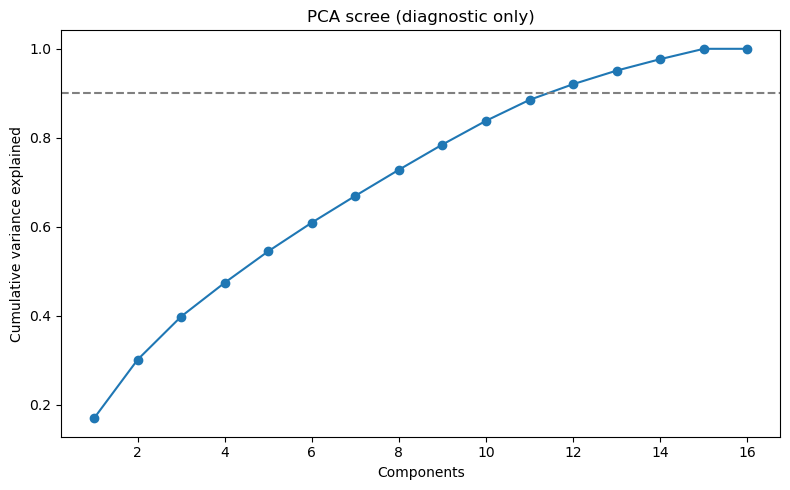

In [ ]:
# Structural check - input factos: checks how many real dimensions of variation exist.
# Note: cluster on the original standardized features, not PCA components. Figure exists only a diagnostic.
pca = PCA().fit(df_scaled)
csum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(csum) + 1), csum, marker="o")
plt.axhline(0.9, ls="--", c="grey")
plt.xlabel("Components"); plt.ylabel("Cumulative variance explained")
plt.title("PCA scree (diagnostic only)")
plt.tight_layout()
plt.show()

PCA Scree Plot does not have a sharp elbow - variance accumulates gradually with no single dominant component (PC1 is only ~17% and takes 11 components to account for the 90% variance).

Features are largely non-redundant - is inputs were still heavily correlated first few components would swallowed most of the variance (curve would shoot up then flatten early).

Note: implication for clustering - high intrinsic dimensionality is slightly harder for K-means (distances get less contrasted as dimensions grow).

General approach to PCA scree plot analysis
- The elbow — where the curve bends from steep to flat. That kink marks the number of components capturing the "real" structure before you hit diminishing returns (mostly noise after). A sharp, obvious elbow at component k says "there are k meaningful dimensions here." 
- How fast you reach a variance threshold (ex. 90%). 
    - Few components to threshold = redundant, compressible features. 
    - Many = independent, information-rich features. 

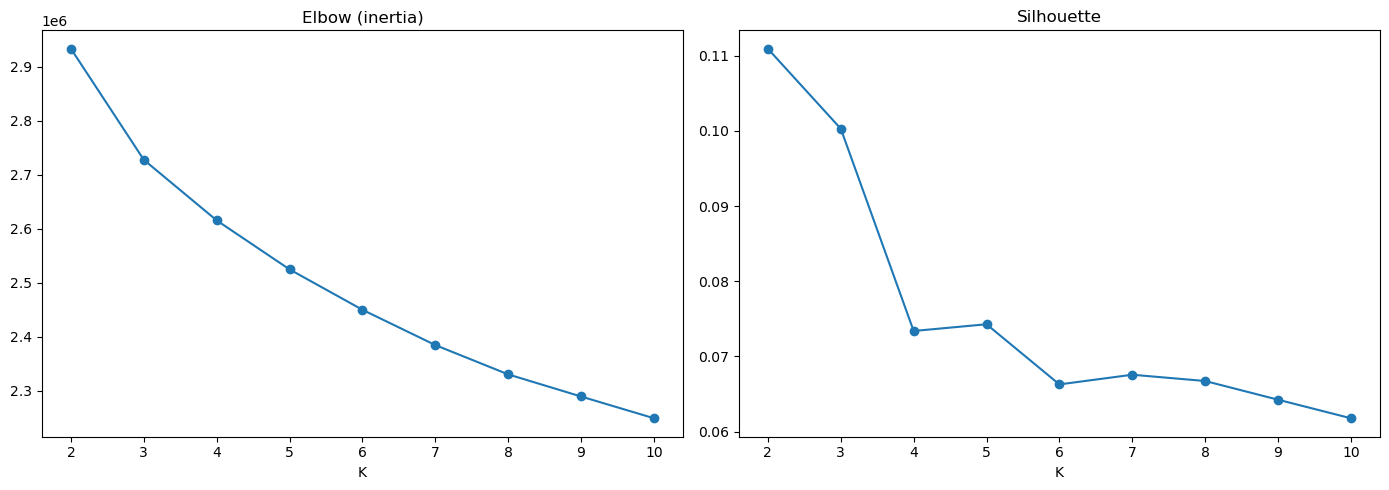

In [27]:
# %% CELL 7 — [ITERATE] Choose K (elbow + silhouette) --------------------------
# WHY two curves: the elbow (inertia) shows diminishing returns; silhouette scores
# separation. Pick a K where silhouette peaks / the elbow bends AND that yields
# describable personas (~4-6 is the practical sweet spot). Silhouette computed on
# a sample for speed on ~200k rows.
Ks = range(2, 11)
inertias, sils = [], []
samp_idx = df_scaled.sample(min(20000, len(df_scaled)), random_state=1).index
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=1).fit(df_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(df_scaled.loc[samp_idx], km.predict(df_scaled.loc[samp_idx])))
 
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(Ks), inertias, marker="o"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("K")
ax[1].plot(list(Ks), sils, marker="o");     ax[1].set_title("Silhouette");      ax[1].set_xlabel("K")
plt.tight_layout(); plt.show()
 
K = 5   # <-- SET after viewing; cross-check against the dendrogram (CELL 9)
 

### Temporary author notes:

Hierarchical clustering run on a 30K subsample due to its O(n²) memory footprint; used to validate K and structure.

Note:
- read the dendrogram for choosing K 
- cross-check that the same persona structure appears



import threading
print(len(threading.enumerate()))
threading.enumerate()

When to down-weight — a defensible rule. Down-weighting is for when a group of columns represents one conceptual axis but occupies many columns, so it dominates the distance purely by count. The clean test: does the number of columns in a block exceed the number of conceptual dimensions you want it to contribute? Your CLR block is 7 columns but arguably represents ~2–3 real axes of "what they buy" (fresh-vs-processed, indulgent-vs-staple, etc.). Meanwhile "how they shop" (reorder, discovery, cadence, timing, basket) is also ~5–6 real axes but spread across a similar column count. If composition ends up with disproportionate column count relative to its conceptual importance, K-means will over-weight it.
Two defensible strategies, in order of preference:

Compress rather than down-weight. Run PCA within the CLR block, keep the 2–3 components that capture its real dimensionality, and feed those instead of 7 raw columns. This is principled (you're representing the block by its actual dimensions) and sidesteps arbitrary weights — the cost is the PCA'd composition axes are less directly interpretable, so you'd describe segments' composition from the raw CLR means in profiling (Section 11) while clustering on the components.
Explicit down-weight, only if you want to keep raw interpretable columns: multiply the scaled block by a factor <1 so its total variance contribution roughly matches the behavioural block. The honest way to set the factor isn't by feel — it's to equalize the summed variance (or column count) across the two blocks, and to state the rule you used. Then run it both weighted and unweighted and report whether the personas change; if they don't, the weighting wasn't load-bearing and you note that; if they do, you've learned composition was dominating and the weighting is justified.

Summary: down-weight (or compress) a block when its column count overstates its conceptual importance and you can show the clustering shifts because of it. Don't down-weight on intuition alone — demonstrate the sensitivity.

The trajectory features (as targets - not inputs). Avg basket size early-vs-late, and avg cadence early-vs-late, are measuring how a customer's engagement changes over their lifecycle. Hold retention/engagement-trajectory out deliberately so the segments could explain it. 

"Do Convenience Shoppers show declining basket size over their lifecycle while Staples Buyers hold steady" is a genuinely good product finding, and it only works if trajectory was never an input.

Only analyze for customers that have greater than ?10?? orders???